# Clustering Analysis
#### Identifyng different categories of shoppers and understand their shopping

## Dataset Path : https://raw.githubusercontent.com/swapnilsaurav/AIML/refs/heads/main/ML/Clustering-Retail-Customers/retail_customer_clustering.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

### Cleaning the data before analysis

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/swapnilsaurav/AIML/refs/heads/main/ML/Clustering-Retail-Customers/retail_customer_clustering.csv")

In [4]:
df.head(10)

,Customer_ID,Age,Gender,City,Signup_Date,Annual_Income_INR,Total_Spend_12M_INR,Purchase_Frequency_12M,Avg_Order_Value_INR,Days_Since_Last_Purchase,Discount_Usage_Pct,Online_Purchase_Pct,App_Visits_Per_Month,Returns_Pct,Categories_Purchased,Loyalty_Points,Customer_Tenure_Months,Campaign_Response_Rate_Pct,Preferred_Channel
0,CUST01861,39,Male,Chennai,2023-08-29,1180004.0,78897.0,15,7607.0,5,13.3,88.2,23.0,15.4,6,4017,37,39.0,Mobile App
1,CUST00354,18,Male,Pune,2023-06-25,1620808.0,60324.0,14,4773.0,12,24.5,99.6,22.0,4.8,8,3317,39,60.3,Mobile App
2,CUST01334,59,Male,Delhi,2022-02-09,875248.0,46379.0,6,7461.0,189,52.9,47.5,6.0,1.0,1,2669,55,19.5,Website
3,CUST00906,35,Female,Chennai,2026-01-20,870223.0,51190.0,18,2653.0,24,31.8,99.8,20.0,16.2,5,2566,7,75.0,Mobile App
4,CUST01290,36,Male,Bengaluru,2023-11-29,1183226.0,78450.0,18,4492.0,17,32.7,90.6,22.0,10.7,8,4428,34,80.8,Website
5,CUST01274,33,Female,Ahmedabad,2025-09-24,1057263.0,104341.0,31,3543.0,14,15.1,91.2,21.0,7.4,5,3985,11,11.8,Mobile App
6,CUST00939,22,Female,Ahmedabad,2026-08-03,615851.0,11459.0,5,2152.0,153,71.9,8.9,1.0,9.5,4,1312,1,0.0,Website
7,CUST01732,47,Female,Chennai,2023-04-03,962271.0,107908.0,31,2828.0,25,6.7,100.0,13.0,8.2,11,5737,42,59.0,Mobile App
8,CUST00066,27,Female,Chennai,2025-05-22,1453535.0,73586.0,34,2209.0,15,30.2,92.0,29.0,8.7,11,3447,16,61.7,Website
9,CUST01324,59,Male,Chennai,2021-04-16,1818398.0,173570.0,6,29449.0,64,NaN,45.5,10.0,0.0,3,7202,65,43.1,Mobile App


In [5]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_ID                 2000 non-null   str    
 1   Age                         2000 non-null   int64  
 2   Gender                      2000 non-null   str    
 3   City                        2000 non-null   str    
 4   Signup_Date                 2000 non-null   str    
 5   Annual_Income_INR           1970 non-null   float64
 6   Total_Spend_12M_INR         2000 non-null   float64
 7   Purchase_Frequency_12M      2000 non-null   int64  
 8   Avg_Order_Value_INR         2000 non-null   float64
 9   Days_Since_Last_Purchase    2000 non-null   int64  
 10  Discount_Usage_Pct          1976 non-null   float64
 11  Online_Purchase_Pct         2000 non-null   float64
 12  App_Visits_Per_Month        1980 non-null   float64
 13  Returns_Pct                 2000 non-null   

(2000, 19)

In [6]:
df.describe(include = "all")

,Customer_ID,Age,Gender,City,Signup_Date,Annual_Income_INR,Total_Spend_12M_INR,Purchase_Frequency_12M,Avg_Order_Value_INR,Days_Since_Last_Purchase,Discount_Usage_Pct,Online_Purchase_Pct,App_Visits_Per_Month,Returns_Pct,Categories_Purchased,Loyalty_Points,Customer_Tenure_Months,Campaign_Response_Rate_Pct,Preferred_Channel
count,2000,2000.000000,2000,2000,2000,1.970000e+03,2000.000000,2000.00000,2000.000000,2000.000000,1976.000000,2000.000000,1980.000000,2000.000000,2000.000000,2000.000000,2000.000000,1976.000000,2000
unique,2000,NaN,3,8,1362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,CUST01861,NaN,Male,Chennai,2026-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mobile App
freq,1,NaN,985,288,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,765
mean,NaN,37.759000,NaN,NaN,NaN,1.284267e+06,71049.057500,16.31750,6367.578500,51.353500,40.053947,63.478700,13.876768,7.168000,5.740500,3587.422000,44.350000,44.310223,NaN
std,NaN,11.329832,NaN,NaN,NaN,6.428431e+05,41393.555613,9.30876,8046.717045,68.554339,25.373542,25.307179,9.950457,4.707368,2.544287,1773.347589,24.330752,24.324553,NaN
min,NaN,18.000000,NaN,NaN,NaN,2.500000e+05,3000.000000,1.00000,300.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,NaN
25%,NaN,29.000000,NaN,NaN,NaN,8.442465e+05,38651.000000,7.00000,2758.000000,11.000000,18.400000,45.075000,5.000000,3.600000,4.000000,2328.750000,26.000000,24.100000,NaN
50%,NaN,37.000000,NaN,NaN,NaN,1.131678e+06,65020.500000,18.00000,3957.500000,20.500000,35.300000,64.000000,13.000000,6.800000,6.000000,3488.000000,43.000000,45.900000,NaN
75%,NaN,45.000000,NaN,NaN,NaN,1.590649e+06,98060.250000,24.00000,6116.250000,54.000000,60.625000,86.600000,21.000000,10.100000,8.000000,4653.500000,60.000000,62.625000,NaN


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Customer_ID'].value_counts()

Customer_ID
CUST01861    1
CUST00354    1
CUST01334    1
CUST00906    1
CUST01290    1
            ..
CUST01131    1
CUST01295    1
CUST00861    1
CUST01460    1
CUST01127    1
Name: count, Length: 2000, dtype: int64

### Feature Selection

In [9]:
df1 = df.drop(columns = ['Customer_ID','Gender','City','Preferred_Channel','Signup_Date'])

In [10]:
df1.head()

,Age,Annual_Income_INR,Total_Spend_12M_INR,Purchase_Frequency_12M,Avg_Order_Value_INR,Days_Since_Last_Purchase,Discount_Usage_Pct,Online_Purchase_Pct,App_Visits_Per_Month,Returns_Pct,Categories_Purchased,Loyalty_Points,Customer_Tenure_Months,Campaign_Response_Rate_Pct
0,39,1180004.0,78897.0,15,7607.0,5,13.3,88.2,23.0,15.4,6,4017,37,39.0
1,18,1620808.0,60324.0,14,4773.0,12,24.5,99.6,22.0,4.8,8,3317,39,60.3
2,59,875248.0,46379.0,6,7461.0,189,52.9,47.5,6.0,1.0,1,2669,55,19.5
3,35,870223.0,51190.0,18,2653.0,24,31.8,99.8,20.0,16.2,5,2566,7,75.0
4,36,1183226.0,78450.0,18,4492.0,17,32.7,90.6,22.0,10.7,8,4428,34,80.8


In [11]:
df1.columns

Index(['Age', 'Annual_Income_INR', 'Total_Spend_12M_INR',
       'Purchase_Frequency_12M', 'Avg_Order_Value_INR',
       'Days_Since_Last_Purchase', 'Discount_Usage_Pct', 'Online_Purchase_Pct',
       'App_Visits_Per_Month', 'Returns_Pct', 'Categories_Purchased',
       'Loyalty_Points', 'Customer_Tenure_Months',
       'Campaign_Response_Rate_Pct'],
      dtype='str')

# Exploratory Data Analysis

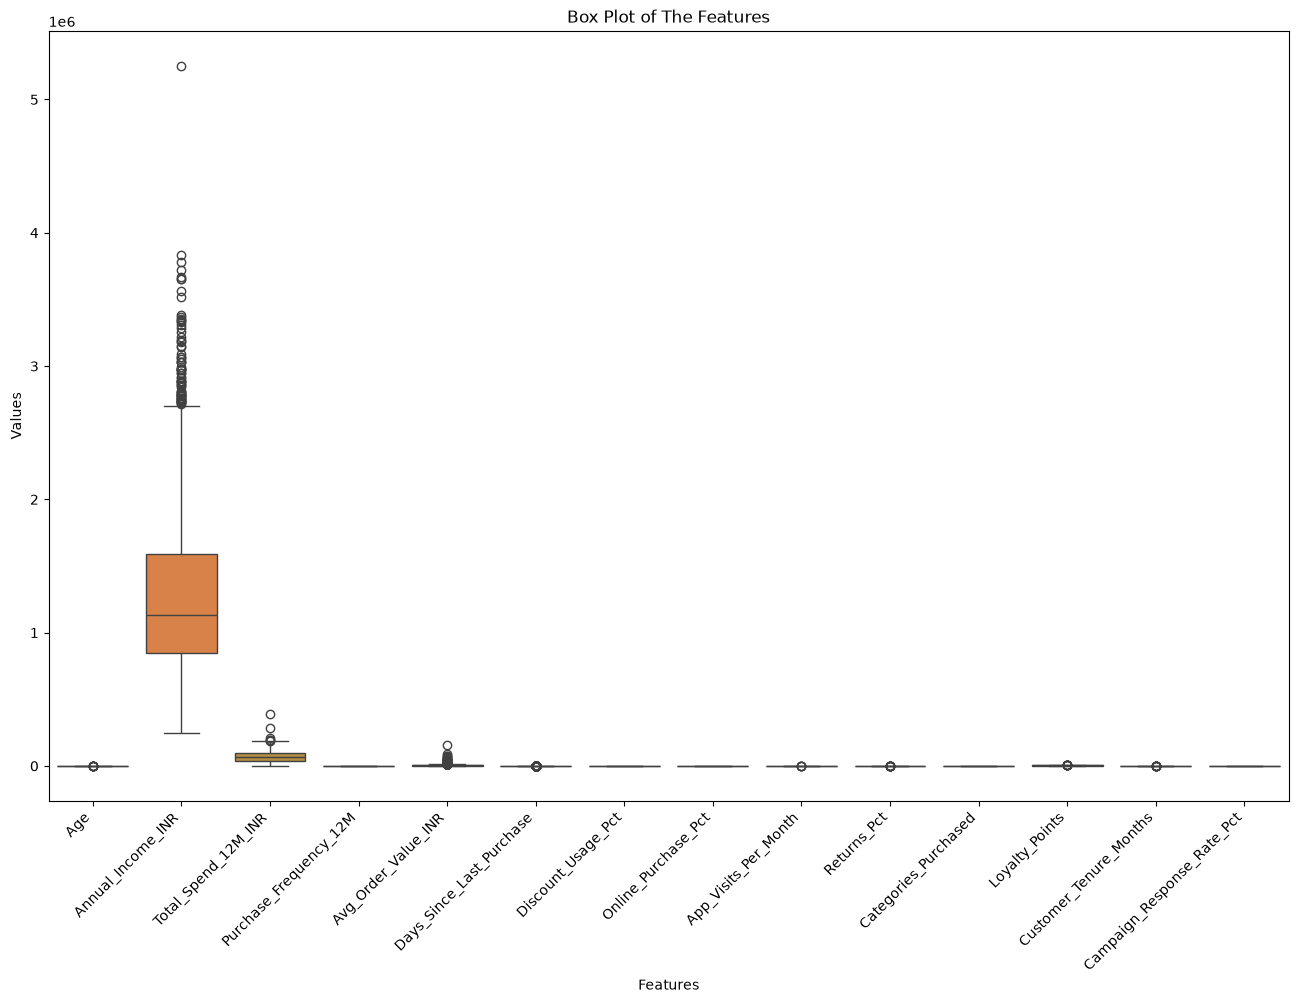

In [12]:
# Before Scaling
plt.figure(figsize = (16,10))
sns.boxplot(data = df1)
plt.xticks(rotation = 45, ha = 'right')
plt.title("Box Plot of The Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

### Outlier Treatment (IQR Capping)
The boxplot above shows several features with heavy outliers. K-Means is distance-based and sensitive to extreme values, 
so we cap (winsorize) outliers using the IQR rule before imputing/scaling, instead of leaving them untreated.

Text(0.5, 0, 'Features')

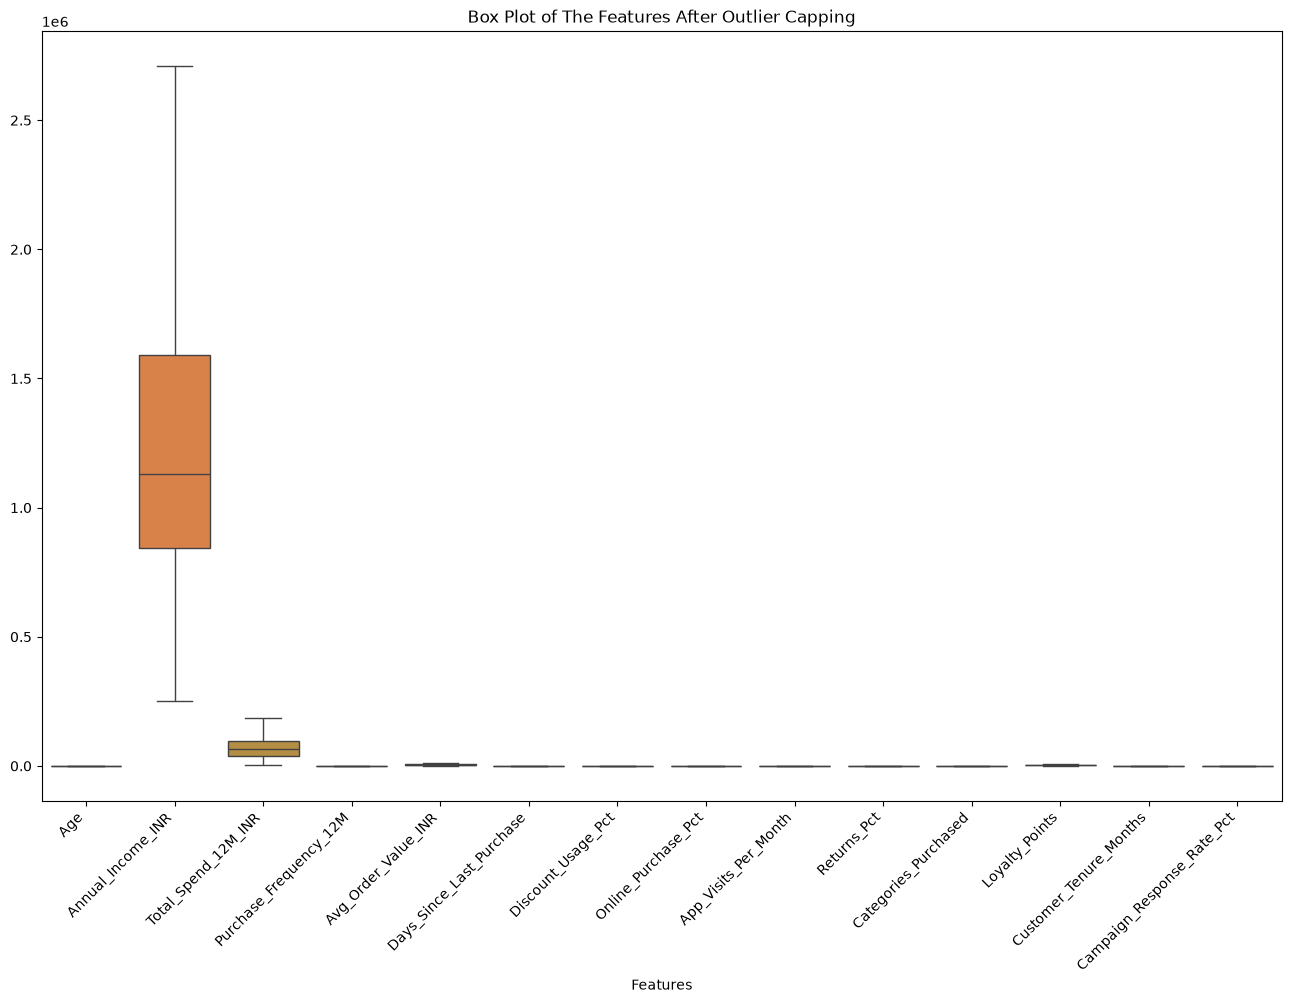

In [13]:
def cap_outliers_iqr(data, cols=None, factor=1.5):
    """Cap outliers to [Q1 - factor*IQR, Q3 + factor*IQR] per column."""
    data = data.copy()
    if cols is None:
        cols = data.select_dtypes(include=np.number).columns
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
        data[col] = data[col].clip(lower=lower, upper=upper)
    return data

df1 = cap_outliers_iqr(df1)

plt.figure(figsize=(16, 10))
sns.boxplot(data=df1)
plt.xticks(rotation=45, ha='right')
plt.title("Box Plot of The Features After Outlier Capping")
plt.xlabel("Features")

### Multicollinearity Check
Before scaling, check for redundant/highly correlated features. K-Means uses Euclidean distance, so two near-duplicate features effectively 
double-count the same signal.

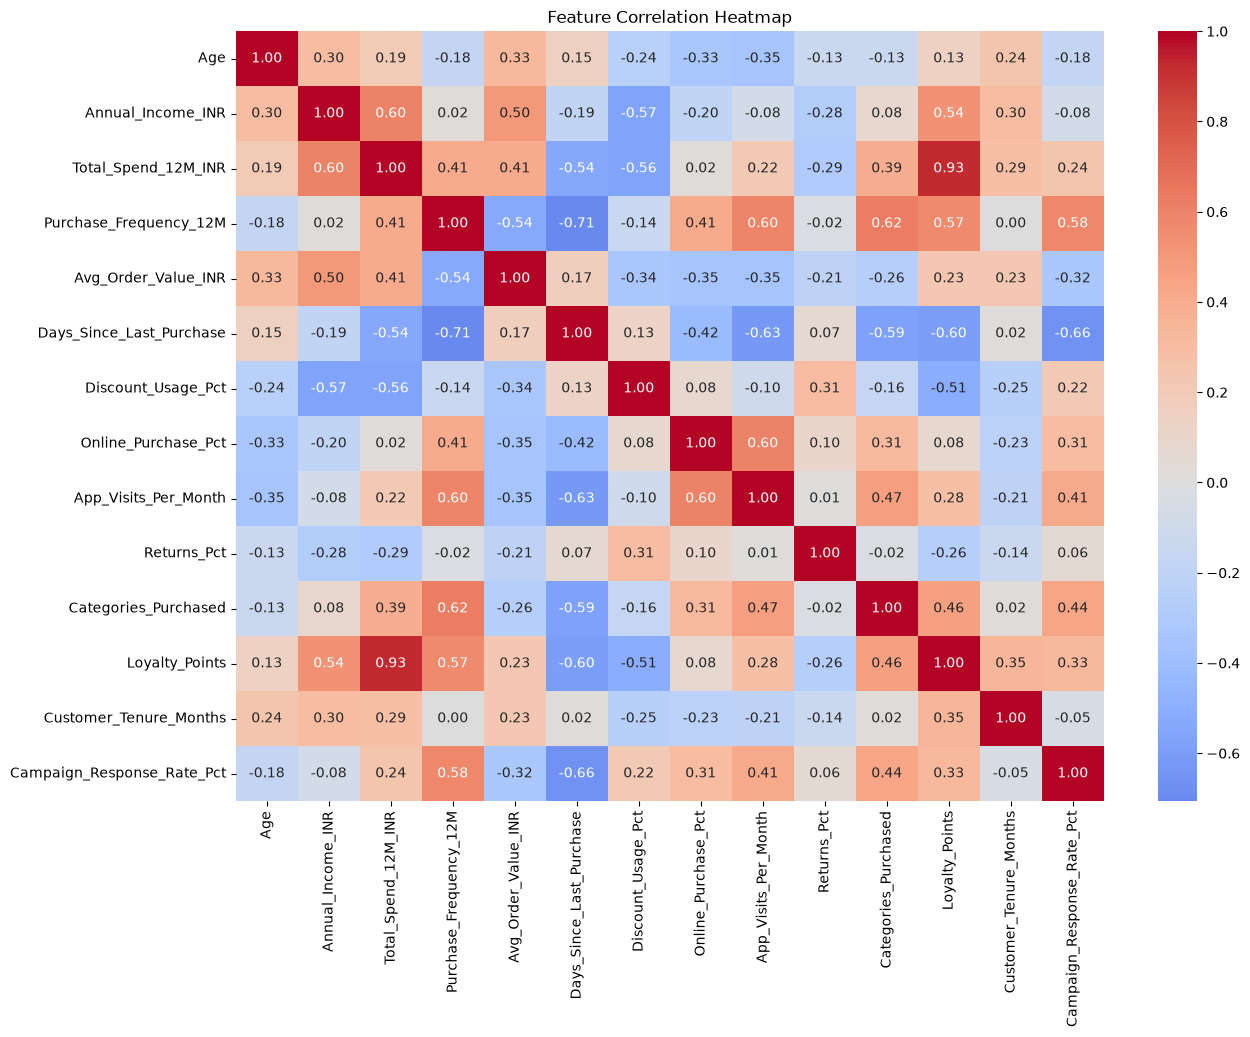

Highly correlated feature pairs (|r| > 0.8):
Total_Spend_12M_INR  Loyalty_Points    0.92664
dtype: float64


In [14]:
plt.figure(figsize=(14, 10))
corr = df1.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

# Flag highly correlated pairs (|r| > 0.8)
corr_abs = corr.abs()
pairs = (
    corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
high_corr = pairs[pairs > 0.8]
print("Highly correlated feature pairs (|r| > 0.8):")
print(high_corr)

`Loyalty_Points` is redundant with `Total_Spend_12M_INR` (r ≈ 0.91) — both largely encode the same "how much this customer spends/engages" signal.
 Dropping one avoids letting that signal count twice in the distance calculation.

In [15]:
df1 = df1.drop(columns=['Loyalty_Points'])
df1.columns

Index(['Age', 'Annual_Income_INR', 'Total_Spend_12M_INR',
       'Purchase_Frequency_12M', 'Avg_Order_Value_INR',
       'Days_Since_Last_Purchase', 'Discount_Usage_Pct', 'Online_Purchase_Pct',
       'App_Visits_Per_Month', 'Returns_Pct', 'Categories_Purchased',
       'Customer_Tenure_Months', 'Campaign_Response_Rate_Pct'],
      dtype='str')

## Simple Imputation

In [16]:
imputer = SimpleImputer(strategy = "median")
data_imputed = imputer.fit_transform(df1)

## Scaling The Data

In [17]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)

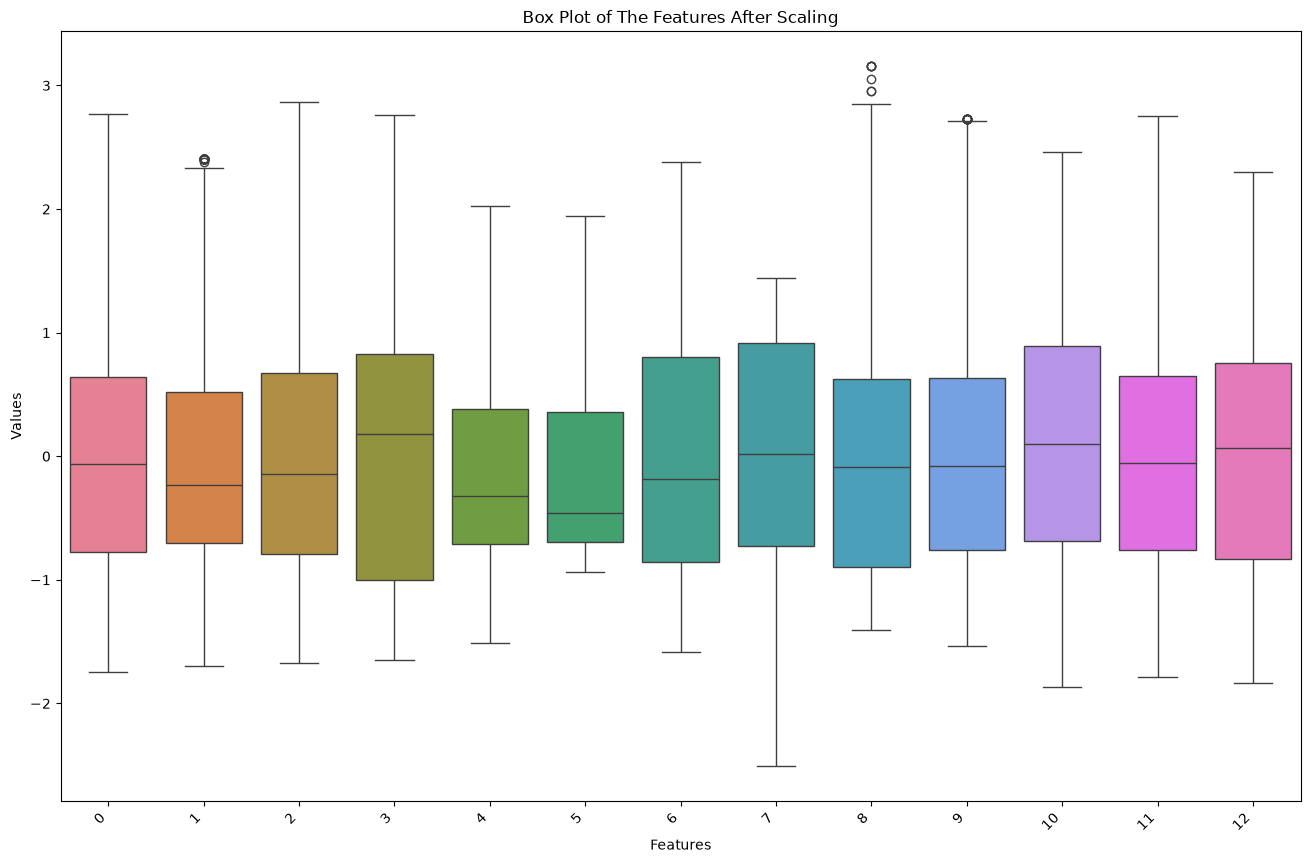

In [18]:
# After Scaling
plt.figure(figsize = (16,10))
sns.boxplot(data = data_scaled)
plt.xticks(rotation = 45, ha = 'right')
plt.title("Box Plot of The Features After Scaling")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

# How many clusters you need for K - Means (2 Methods)

## 1. Elbow Method

In [19]:
from sklearn.cluster import KMeans

K=2, Inertia=18780.45
K=3, Inertia=15045.33
K=4, Inertia=12744.94
K=5, Inertia=11003.24
K=6, Inertia=10599.70
K=7, Inertia=10370.08
K=8, Inertia=10009.95
K=9, Inertia=9781.82
K=10, Inertia=9555.37


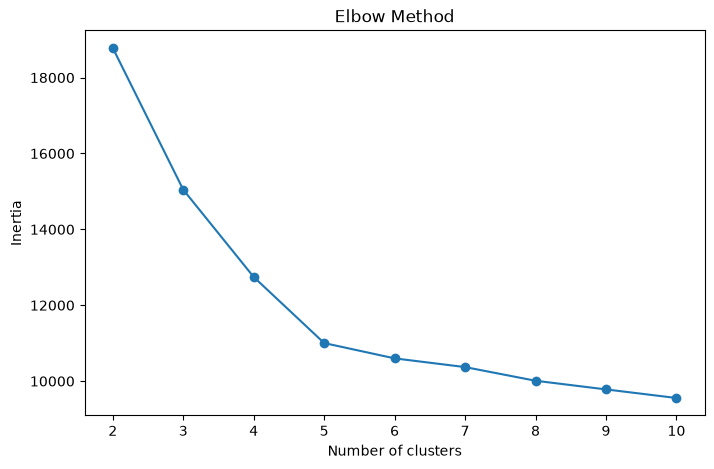

In [20]:
inertia = []
for k in range(2,11):
    kmean = KMeans(n_clusters = k, random_state = 42, n_init =10)
    kmean.fit(data_scaled)
    inertia.append(kmean.inertia_)
    print(f"K={k}, Inertia={kmean.inertia_:.2f}")
plt.figure(figsize = (8,5))
plt.plot(range(2,11),inertia,marker = 'o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

After K = 5 the curve becomes flatter.So the elbow appears to be around K = 5

## 2. Silhouette Score

In [21]:
from sklearn.metrics import silhouette_score

K= 2 Score= 0.29031542658467313
K= 3 Score= 0.28334824089694644
K= 4 Score= 0.282270563798397
K= 5 Score= 0.2683102006993142
K= 6 Score= 0.23450344473422252
K= 7 Score= 0.23005868706243524
K= 8 Score= 0.17003679463449786
K= 9 Score= 0.1661332527684162
K= 10 Score= 0.13646785816204174


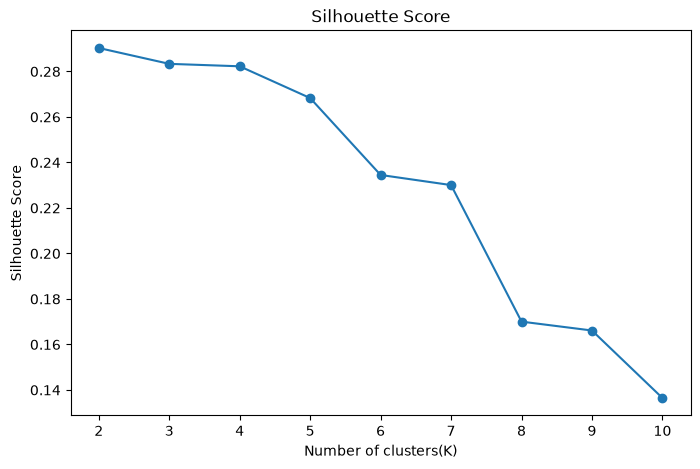

In [22]:
silhouette_scores = []
for k in range(2,11):
    kmean = KMeans(n_clusters = k,random_state = 42,n_init =10)
    labels = kmean.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    silhouette_scores.append(score)
    print("K=",k,"Score=",score)
plt.figure(figsize = (8,5))
plt.plot(range(2,11),silhouette_scores,marker = 'o')
plt.title("Silhouette Score")
plt.xlabel("Number of clusters(K)")
plt.ylabel("Silhouette Score")
plt.show()

Highest Silhouette score = 0.29479392758917117 for K = 4

#### Number Of Clusters = 4

In [23]:
kmean = KMeans(n_clusters = 4,random_state = 42, n_init = 10)
clusters = kmean.fit_predict(data_scaled)

In [24]:
df1['Clusters'] = clusters

In [25]:
df1.head(10)

,Age,Annual_Income_INR,Total_Spend_12M_INR,Purchase_Frequency_12M,Avg_Order_Value_INR,Days_Since_Last_Purchase,Discount_Usage_Pct,Online_Purchase_Pct,App_Visits_Per_Month,Returns_Pct,Categories_Purchased,Customer_Tenure_Months,Campaign_Response_Rate_Pct,Clusters
0,39,1180004.0,78897.0,15,7607.000,5.0,13.3,88.2,23.0,15.4,6,37,39.0,0
1,18,1620808.0,60324.0,14,4773.000,12.0,24.5,99.6,22.0,4.8,8,39,60.3,0
2,59,875248.0,46379.0,6,7461.000,118.5,52.9,47.5,6.0,1.0,1,55,19.5,1
3,35,870223.0,51190.0,18,2653.000,24.0,31.8,99.8,20.0,16.2,5,7,75.0,0
4,36,1183226.0,78450.0,18,4492.000,17.0,32.7,90.6,22.0,10.7,8,34,80.8,0
5,33,1057263.0,104341.0,31,3543.000,14.0,15.1,91.2,21.0,7.4,5,11,11.8,0
6,22,615851.0,11459.0,5,2152.000,118.5,71.9,8.9,1.0,9.5,4,1,0.0,1
7,47,962271.0,107908.0,31,2828.000,25.0,6.7,100.0,13.0,8.2,11,42,59.0,3
8,27,1453535.0,73586.0,34,2209.000,15.0,30.2,92.0,29.0,8.7,11,16,61.7,0
9,59,1818398.0,173570.0,6,11153.625,64.0,NaN,45.5,10.0,0.0,3,65,43.1,2


## PCA - Feature Reduction

In [26]:
from sklearn.decomposition import PCA

In [27]:
pca = PCA(n_components=2)
pca_scaled = pca.fit_transform(data_scaled)
pca_df = pd.DataFrame(pca_scaled[:,:2], columns = ['PC1','PC2'])
pca_df['Clusters'] = clusters
pca_df.head()

,PC1,PC2,Clusters
0,0.787920,0.241667,0
1,1.786131,0.001272,0
2,-3.520362,-0.088395,1
3,1.604708,-1.833523,0
4,1.972393,-0.238898,0


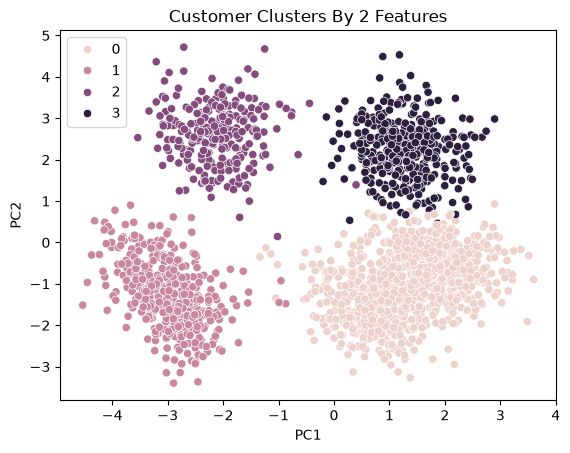

In [28]:
sns.scatterplot(data = pca_df, x = 'PC1', y= 'PC2',hue = clusters)
plt.title("Customer Clusters By 2 Features")
plt.show()

# Cluster Profiling
The step the original notebook was missing: actually describing what each cluster looks like, so we can talk about "types of shoppers" instead of just cluster numbers.

In [29]:
print("Cluster sizes:")
print(df1['Clusters'].value_counts().sort_index())

Cluster sizes:
Clusters
0    960
1    416
2    255
3    369
Name: count, dtype: int64


In [30]:
cluster_profile = df1.groupby('Clusters').mean(numeric_only=True).round(1)
cluster_profile

,Age,Annual_Income_INR,Total_Spend_12M_INR,Purchase_Frequency_12M,Avg_Order_Value_INR,Days_Since_Last_Purchase,Discount_Usage_Pct,Online_Purchase_Pct,App_Visits_Per_Month,Returns_Pct,Categories_Purchased,Customer_Tenure_Months,Campaign_Response_Rate_Pct
Clusters,,,,,,,,,,,,,
0,32.0,979746.2,61512.1,20.0,3340.4,18.2,53.9,78.9,20.1,8.3,6.5,34.3,58.4
1,40.2,919018.5,22540.2,5.0,5075.2,110.7,45.8,45.6,3.0,8.0,3.1,44.2,12.4
2,47.2,2211062.1,108238.4,6.0,10965.2,42.8,19.2,42.5,6.0,4.3,4.0,55.4,29.7
3,43.3,1771869.7,123927.1,26.8,4783.3,11.3,12.5,58.0,15.3,5.0,8.1,62.8,53.9


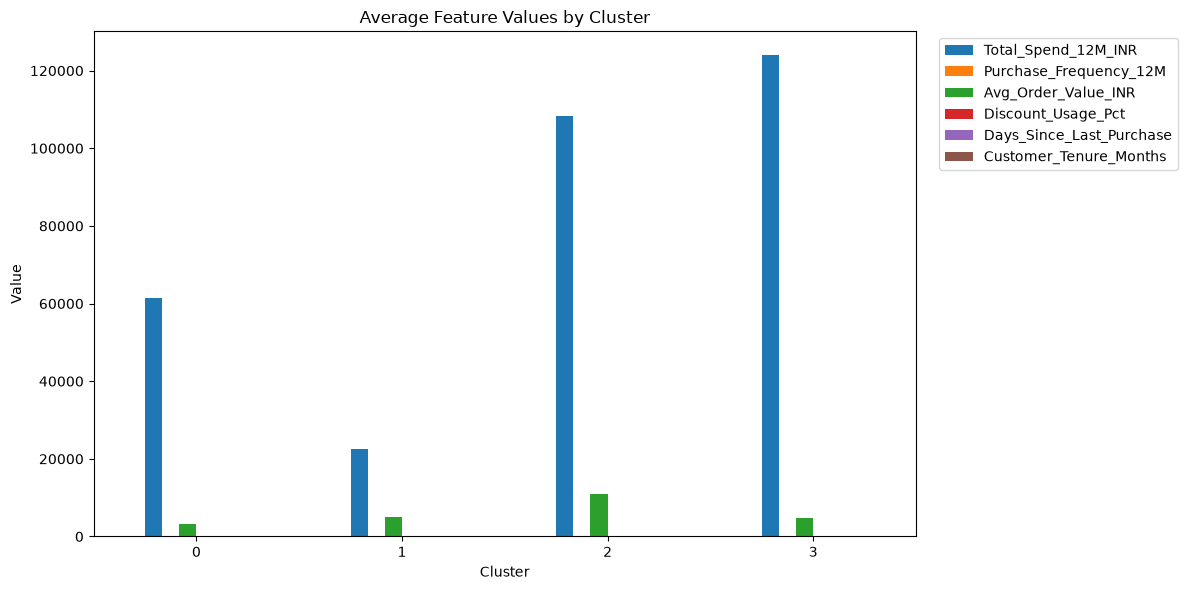

In [31]:
key_features = ['Total_Spend_12M_INR', 'Purchase_Frequency_12M', 'Avg_Order_Value_INR',
                'Discount_Usage_Pct', 'Days_Since_Last_Purchase', 'Customer_Tenure_Months']

cluster_profile[key_features].plot(kind='bar', figsize=(12, 6))
plt.title("Average Feature Values by Cluster")
plt.ylabel("Value")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Bring back the categorical columns that were dropped earlier (`Gender`, `City`, `Preferred_Channel`) to see how they break down within each cluster
— useful context even though they weren't used to form the clusters.

In [32]:
profile_df = df.copy()
profile_df['Clusters'] = df1['Clusters'].values

for col in ['Gender', 'City', 'Preferred_Channel']:
    print(f"\n{col} distribution by cluster (%):")
    print((pd.crosstab(profile_df['Clusters'], profile_df[col], normalize='index') * 100).round(1))


Gender distribution by cluster (%):
Gender    Female  Male  Other
Clusters                     
0           46.2  51.5    2.3
1           47.1  51.4    1.4
2           52.5  45.9    1.6
3           54.7  43.4    1.9

City distribution by cluster (%):
City      Ahmedabad  Bengaluru  Chennai  Delhi  Hyderabad  Kolkata  Mumbai  \
Clusters                                                                     
0              12.7       12.5     14.0   11.0       12.2     11.4    12.8   
1              13.7       13.9     14.2   11.5        9.6     11.1    13.5   
2              11.4       10.2     14.1   14.5       12.5     12.2    12.9   
3              11.4       11.9     16.0   12.5       13.6     11.7    11.1   

City      Pune  
Clusters        
0         13.4  
1         12.5  
2         12.2  
3         11.9  

Preferred_Channel distribution by cluster (%):
Preferred_Channel  Mobile App  Store  Website
Clusters                                     
0                        52.6   14.6 

## Cluster Stability Check
K-Means depends on initialization. `n_init=10` already reruns with multiple centroid seeds internally, 
but as an extra sanity check we compare the final labeling across several different `random_state` values using the Adjusted Rand Index (ARI). 
Scores close to 1.0 mean the 4-cluster structure is stable and not an artifact of one seed.

In [33]:
from sklearn.metrics import adjusted_rand_score

base_labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(data_scaled)

ari_scores = []
for seed in [0, 1, 7, 99, 123]:
    labels = KMeans(n_clusters=4, random_state=seed, n_init=10).fit_predict(data_scaled)
    ari = adjusted_rand_score(base_labels, labels)
    ari_scores.append(ari)
    print(f"Seed={seed}, ARI vs random_state=42 solution: {ari:.3f}")

print(f"\nMean ARI: {np.mean(ari_scores):.3f} (closer to 1.0 = more stable clustering)")

Seed=0, ARI vs random_state=42 solution: 1.000
Seed=1, ARI vs random_state=42 solution: 1.000
Seed=7, ARI vs random_state=42 solution: 1.000
Seed=99, ARI vs random_state=42 solution: 1.000
Seed=123, ARI vs random_state=42 solution: 1.000

Mean ARI: 1.000 (closer to 1.0 = more stable clustering)
